# Customer Churn Prediction
## Objective
Utilize machine learning techniques such as Decision Tree, Random Forest, and Light GBM to determine whether customers will churn. Evaluate these techniques using metrics such as accuracy, precision, recall, f1-score, confusion matrix and ROC-AUC score.

## Dataset
This dataset was originally part of IBM's Sample Datasets. It contains information such as whether customers left within the last month (the Churn column), services that the customer has signed up for (i.e. phone, internet, tech support), customer account information (i.e. payment method, how long they have been a customer, monthly charges) and customer demographic information (i.e. gender, age range, whether they have dependents).

Source: Kaggle download


## Data Loading and Inspection
Import necessary libraries, download the dataset, and explore its content.

In [1]:
import pandas as pd
import numpy as np

In [2]:
Churn = pd.read_csv("/content/Telco Customer Churn.csv")
Churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
Churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


As shown above, the dataset has 7043 rows, none of which contain null values and 21 columns, most of which are categorical in nature. These categorical columns will need to be encoded. It is important to note that the TotalCharges columns is considered to have an object data type though it is numeric in nature. This will need to be fixed.

In [ ]:
Churn.duplicated().sum()

np.int64(0)

No duplicates are present.

In [ ]:
Churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


It is evident that the SeniorCitizen column is actually a categorical column since it only contains 0s and 1s with 1 indicating that a customer is a senior citizen and 0 indicating otherwise. The other two columns, tenure and MonthlyCharges, are numerical columns that have a continuous distributuion.

In [ ]:
Churn["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


It is clear that the dataset has a significant imbalance favoring non-churners over churners. This will need to be taken into account.

## Data Preparation
Encode the target variable Churn and all of the object data type variables aside from TotalCharges so they can easily be fed into the machine learning model. For TotalCharges, change its data type to numeric.

In [4]:
# Target
y = Churn["Churn"].map({"No": 0, "Yes": 1})

# Predictors
X = Churn.drop(columns=["Churn", "customerID"])

# Convert TotalCharges to numeric
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

# One-hot encode predictors only
X = pd.get_dummies(X, drop_first=True, dtype=int)

print(X.shape)
print(y.value_counts())

(7043, 30)
Churn
0    5174
1    1869
Name: count, dtype: int64


## Model Training and Evaluation
Split the dataset into testing and training sets, fit the Decision Tree, Random Forest, and Light GBM models on the training set, and evaluate them based on accuracy, precision, recall, f1 score, confusion matrix, and the ROC AUC score.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

In [6]:
dt_model = DecisionTreeClassifier(class_weight = 'balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy}")



Decision Tree Accuracy: 0.7409510290986515


In [7]:
dt_report = classification_report(y_test, dt_pred)
print("Decision Tree Classification Report:")
print(dt_report)
#

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1036
           1       0.51      0.49      0.50       373

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



In [8]:
from sklearn.metrics import roc_auc_score

# Predicted probabilities for the positive class
y_prob = dt_model.predict_proba(X_test)[:, 1]

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.662


It is noteworthy that even though Decision Tree has an accuracy of 74%, it performs much better for non-churners than for churners, getting precision, recall, and f1 score metrics that are respectively 82%, 83%, and 82% for the former and 51%, 49%, and 50% for the latter. Based on this, the model evidently misclassifies churners at a higher rate than non-churners. The ROC-AUC score 0.662 indicates the model does only somewhat well at distinguishing between the two classes at all thresholds.

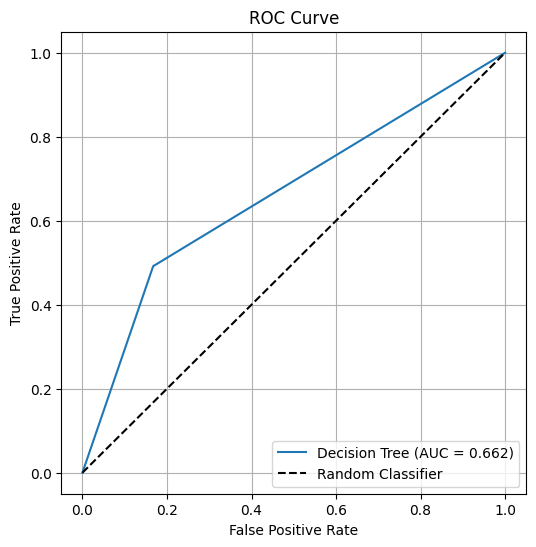

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities
y_prob = dt_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

In [10]:
rf_model = RandomForestClassifier(class_weight = 'balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy}")
#

Random Forest Accuracy: 0.7991483321504613


In [11]:
rf_report = classification_report(y_test, rf_pred)
print("Random Forest Classification Report:")
print(rf_report)
#

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [12]:
# Predicted probabilities for the positive class
y_prob = rf_model.predict_proba(X_test)[:, 1]

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.840


Random Forest does better overall. Its accuracy is higher (approximately 80%) and while there is an evident disparity in precision, recall, and f1 score between churners and non-churners, it is significantly less than for Decision Tree. For instance, precision for churners is 67%, indicating that a higher percentage of positive churn predictions are actually positive. Consequently, the f1 score is 55%, significantly higher than for Decision Tree. The ROC-AUC score 0.84 indicates the model does a pretty decent job of distinguishing between the two classes at all thresholds.

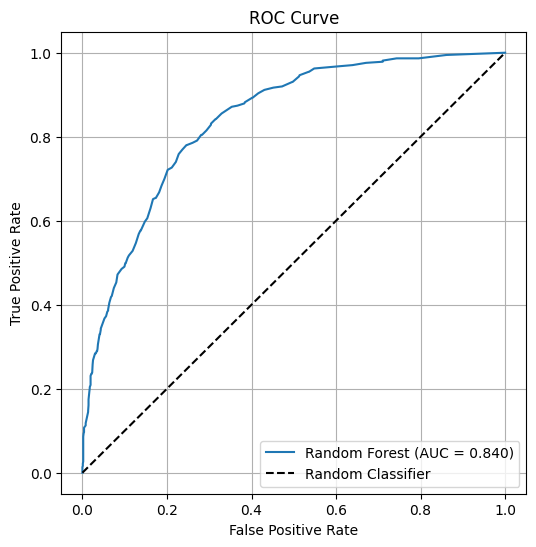

In [13]:
# Predicted probabilities
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

In [14]:
lgb_model = lgb.LGBMClassifier(class_weight = 'balanced', random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_accuracy = accuracy_score(y_test, lgb_pred)
print(f"LightGBM Accuracy: {lgb_accuracy}")
#


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM Accuracy: 0.7650816181689141


In [15]:
lgb_report = classification_report(y_test, lgb_pred)
print("LightGBM Classification Report:")
print(lgb_report)
#

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1036
           1       0.54      0.75      0.63       373

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [16]:
# Predicted probabilities for the positive class
y_prob = lgb_model.predict_proba(X_test)[:, 1]

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.853


It is evident that even though accuracy (approximately 77%) is somewhat lower for Light GBM compared to Random Forest, the recall score for churners is 75%, indicating the overwhelming majority of churners are identified as such. This results in an f1 score of 63% for churners, the highest score of all three models. The ROC-AUC score 0.853 is the highest for all models, indicating the model does a great job of distinguishing between the two classes at all thresholds.

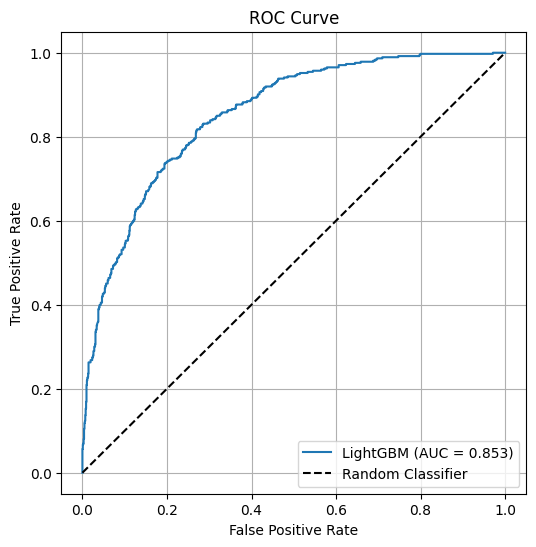

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities
y_prob = lgb_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

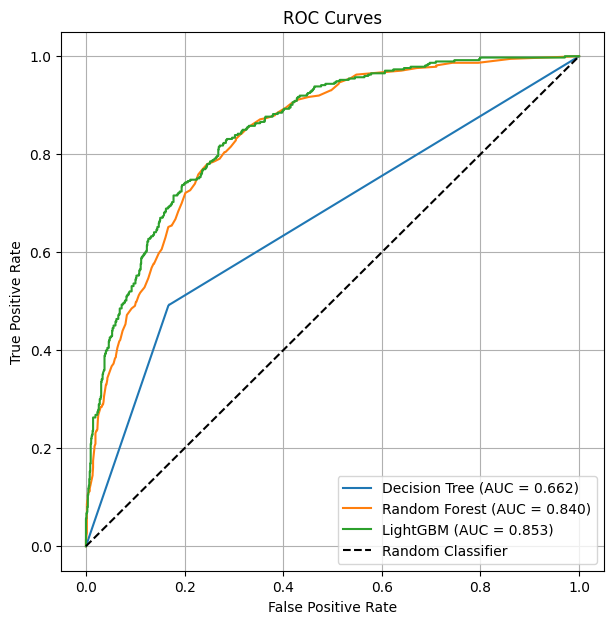

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "LightGBM": lgb_model
}

plt.figure(figsize=(7,7))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1],'k--',label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

In [26]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
feature_groups = {
    "Contract": "Contract",
    "PaymentMethod": "PaymentMethod",
    "InternetService": "InternetService",
    "OnlineSecurity": "OnlineSecurity",
    "OnlineBackup": "OnlineBackup",
    "DeviceProtection": "DeviceProtection",
    "TechSupport": "TechSupport",
    "StreamingTV": "StreamingTV",
    "StreamingMovies": "StreamingMovies",
    "MultipleLines": "MultipleLines",
    "PaperlessBilling": "PaperlessBilling",
    "Partner": "Partner",
    "Dependents": "Dependents",
    "gender": "gender",
    "PhoneService": "PhoneService"
}

def group_feature(feature):
    for prefix in feature_groups:
        if feature.startswith(prefix):
            return feature_groups[prefix]
    return feature

feature_importances["GroupedFeature"] = feature_importances["Feature"].apply(group_feature)

grouped_importance = (
    feature_importances
    .groupby("GroupedFeature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

,Importance
GroupedFeature,
MonthlyCharges,807
TotalCharges,649
tenure,533
PaymentMethod,149
Contract,103
gender,88
PaperlessBilling,87
Partner,70
TechSupport,59


As shown above, since categorical variables were one-hot encoded during preprocessing, feature importances for related dummy variables were aggregated to better represent the influence of the original business variables. Based on this chart, the top three most important features are MonthlyCharges, TotalCharges, and tenure. The top three least important features are InternetService, Dependents, and PhoneService. In other words, financial costs and tenure are much more influential in determining churn status than anything else.

## Conclusion
This project developed and evaluated three machine learning models—Decision Tree, Random Forest, and LightGBM—to predict customer churn using the Telco Customer Churn dataset.

Among the models evaluated:

Decision Tree served as a baseline but achieved the weakest performance (Accuracy = 74.1%, ROC-AUC = 0.662).
Random Forest achieved the highest overall accuracy (79.9%) and strong ROC-AUC (0.840), but identified fewer customers who were likely to churn (Recall = 0.47).
LightGBM achieved the highest ROC-AUC (0.853) and substantially higher recall (0.75), making it the most effective model for identifying customers at risk of churn.

Although Random Forest produced the highest accuracy, accuracy alone is not the most appropriate metric for churn prediction because failing to identify customers who will leave can be more costly than incorrectly flagging customers who would remain. LightGBM's stronger recall makes it the preferred model for customer retention initiatives.

Feature importance analysis showed that the strongest predictors of churn included:

- Monthly charges
- Total charges
- Customer tenure

These findings suggest that pricing and customer longevity have the greatest influence on customer retention.

From a business perspective, the results indicate that the company could reduce churn by:

- Offering retention incentives to newer customers before they cancel.
- Reviewing pricing strategies for customers with higher monthly charges.
- Targeting proactive retention campaigns toward high-risk customers identified by the LightGBM model.

Overall, this project demonstrates how machine learning can support customer retention by accurately identifying customers at risk of churning and providing insights into the factors that most strongly influence customer behavior.